In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Pull 1 year of HSBC data
hsbc = yf.download("HSBA.L", period="1y", auto_adjust=True)

# Flatten the column structure yfinance creates
prices = pd.DataFrame()
prices['price'] = hsbc['Close'].values.flatten()
prices.index = hsbc.index

print("Data shape:", prices.shape)
print(prices.tail())

[*********************100%***********************]  1 of 1 completed

Data shape: (254, 1)
                  price
Date                   
2026-03-16  1195.800049
2026-03-17  1207.199951
2026-03-18  1209.199951
2026-03-19  1171.599976
2026-03-20  1144.199951


In [4]:
# Calculate daily returns
prices['return'] = prices['price'].pct_change() * 100

# Create features (X) — what we use to predict
# We use previous day's return to predict today's return
prices['prev_return'] = prices['return'].shift(1)
prices['prev_2_return'] = prices['return'].shift(2)
prices['prev_3_return'] = prices['return'].shift(3)

# Drop rows with missing values
prices = prices.dropna()

print("Final dataset shape:", prices.shape)
print("\nFirst 5 rows:")
print(prices.head())

Final dataset shape: (250, 5)

First 5 rows:
                 price    return  prev_return  prev_2_return  prev_3_return
Date                                                                       
2025-03-26  895.174194  0.708339     0.315818       0.567151       0.627782
2025-03-27  892.875610 -0.256775     0.708339       0.315818       0.567151
2025-03-28  884.880310 -0.895455    -0.256775       0.708339       0.315818
2025-03-31  873.387085 -1.298845    -0.895455      -0.256775       0.708339
2025-04-01  876.685120  0.377614    -1.298845      -0.895455      -0.256775


In [5]:
# Features (X) — the inputs
X = prices[['prev_return', 'prev_2_return', 'prev_3_return']]

# Target (y) — what we're predicting
y = prices['return']

# 80% train, 20% test — shuffle=False because order matters in time series
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("\nTraining period:", X_train.index[0].date(), "→", X_train.index[-1].date())
print("Test period:    ", X_test.index[0].date(), "→", X_test.index[-1].date())

Training samples: 200
Test samples: 50

Training period: 2025-03-26 → 2026-01-09
Test period:     2026-01-12 → 2026-03-20


In [6]:
# Create and train the model — this is the actual ML happening
model = LinearRegression()
model.fit(X_train, y_train)

# Look at what the model learned
print("=== What the model learned ===")
print(f"Intercept (β₀):        {round(model.intercept_, 6)}")
print(f"Yesterday's return (β₁): {round(model.coef_[0], 6)}")
print(f"2 days ago (β₂):         {round(model.coef_[1], 6)}")
print(f"3 days ago (β₃):         {round(model.coef_[2], 6)}")

=== What the model learned ===
Intercept (β₀):        0.123378
Yesterday's return (β₁): 0.12553
2 days ago (β₂):         0.09091
3 days ago (β₃):         0.005727


In [7]:
# Make predictions on unseen test data
y_pred = model.predict(X_test)

# Measure performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Model Performance on Unseen Data ===")
print(f"R² Score:  {round(r2, 4)}")
print(f"RMSE:      {round(rmse, 4)}%")
print()

# Interpret the R²
if r2 > 0.5:
    print("Interpretation: Strong predictive power")
elif r2 > 0.1:
    print("Interpretation: Weak but real predictive signal")
elif r2 > 0:
    print("Interpretation: Very weak signal — market is mostly efficient")
else:
    print("Interpretation: No predictive power — market is efficient")

=== Model Performance on Unseen Data ===
R² Score:  -0.0398
RMSE:      2.2548%

Interpretation: No predictive power — market is efficient


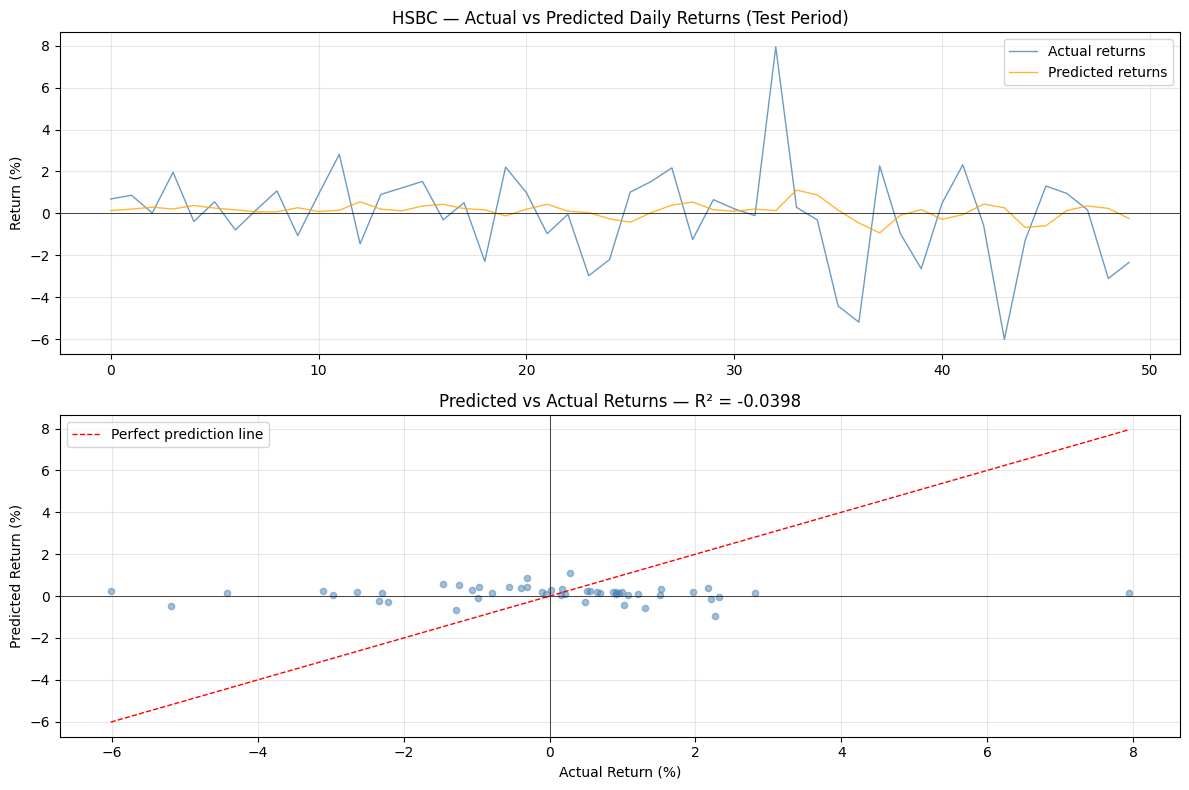

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1 — predicted vs actual returns
ax1.plot(y_test.values, label='Actual returns', 
         color='steelblue', linewidth=1, alpha=0.8)
ax1.plot(y_pred, label='Predicted returns', 
         color='orange', linewidth=1, alpha=0.8)
ax1.set_title('HSBC — Actual vs Predicted Daily Returns (Test Period)')
ax1.set_ylabel('Return (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linewidth=0.5)

# Plot 2 — scatter plot of predicted vs actual
ax2.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.axvline(x=0, color='black', linewidth=0.5)
ax2.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=1, label='Perfect prediction line')
ax2.set_title(f'Predicted vs Actual Returns — R² = {round(r2, 4)}')
ax2.set_xlabel('Actual Return (%)')
ax2.set_ylabel('Predicted Return (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("=" * 50)
print("HSBC STOCK RETURN PREDICTION — SUMMARY")
print("=" * 50)
print(f"""
DATA
  Stock:          HSBC (HSBA.L) — London Stock Exchange
  Period:         March 2025 → March 2026
  Training days:  {len(X_train)}
  Test days:      {len(X_test)}

MODEL
  Algorithm:      Linear Regression (OLS)
  Features:       Previous 1, 2, 3 day returns
  Target:         Next day return

RESULTS
  R² Score:       {round(r2, 4)}
  RMSE:           {round(rmse, 4)}%
  Best feature:   Yesterday's return (β = {round(model.coef_[0], 4)})

CONCLUSION
  Past returns alone have no meaningful predictive 
  power over HSBC's next day return (R² ≈ 0).
  
  This confirms the Efficient Market Hypothesis —
  to find real signal we need richer features:
  - Trading volume and momentum
  - Macro indicators (interest rates, inflation)
  - Sentiment from financial news (NLP)
  - Sector-wide movements
  
  Next step: Add these features and compare.
""")
print("=" * 50)

HSBC STOCK RETURN PREDICTION — SUMMARY

DATA
  Stock:          HSBC (HSBA.L) — London Stock Exchange
  Period:         March 2025 → March 2026
  Training days:  200
  Test days:      50

MODEL
  Algorithm:      Linear Regression (OLS)
  Features:       Previous 1, 2, 3 day returns
  Target:         Next day return

RESULTS
  R² Score:       -0.0398
  RMSE:           2.2548%
  Best feature:   Yesterday's return (β = 0.1255)

CONCLUSION
  Past returns alone have no meaningful predictive 
  power over HSBC's next day return (R² ≈ 0).

  This confirms the Efficient Market Hypothesis —
  to find real signal we need richer features:
  - Trading volume and momentum
  - Macro indicators (interest rates, inflation)
  - Sentiment from financial news (NLP)
  - Sector-wide movements

  Next step: Add these features and compare.

